# Prior-Conditioned Repetition Cue CRP

> Stratify ordinary forward transition lags by the prior recall's offset from repeated-item occurrences.

## Workflow

1. Load selected trial data.
2. Compute subject-level cue CRP arrays once and reuse them for all plots.
3. Plot the refined cue-offset by transition-lag surface, with access-to-repeater cells outlined.
4. Plot the transformed previous-offset by next-offset surface, where repeater access is the next-offset 0 row.
5. Plot access diagonal curves and selected offset-specific ordinary CRPs.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
from jaxcmr.analyses.repcuecrp import (
    _masked_cmap,
    _overlay_access_cells,
    _previous_next_surface,
    subject_rep_cue_crp,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure
from jaxcmr.plotting import plot_data, set_plot_labels

In [2]:
data_paths = [
    "../datasets/prepared/BroitmanKahana2024.h5",
    "../datasets/prepared/LohnasKahana2014.h5",
    "../datasets/prepared/Lohnas2025.h5",
    "../datasets/prepared/HowardKahana2005.h5",
]
trial_queries = [
    "data['listLength'] > 0",
    "data['list_type'] > 2",
    "data['list_type'] == 2",
    "data['condition'] > 0",
]
data_labels = ["BroitmanKahana2024", "LohnasKahana2014", "Lohnas2025", "HowardKahana2005"]
figure_dir = "results/figures"
figure_str = ""
ylim = [0, .45]
min_lag = 4
max_lag = 5
max_offset = max_lag
size = 2
cue_offsets = [-5, -4, -3, -2, -1, 1, 2, 3, 4, 5]
cue_offsets_to_plot = [-2, -1, 1, 2]
confidence_level = 0.95

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
datasets = []
trial_masks = []

for data_path, trial_query in zip(data_paths, trial_queries):
    data_path = os.path.join(project_root, data_path)
    data = load_data(data_path)
    trial_mask = generate_trial_mask(data, trial_query)
    datasets.append(data)
    trial_masks.append(trial_mask)

In [4]:
observed_crps = []
for data, trial_mask in zip(datasets, trial_masks):
    observed_crp = subject_rep_cue_crp(
        data, trial_mask, min_lag, max_lag, max_offset, size
    )
    observed_crps.append(observed_crp)

sources = data_labels
rep_labels = ("First", "Second")

lag_labels = np.arange(-max_lag, max_lag + 1)
cue_offset_labels = np.arange(-max_offset, max_offset + 1)
access_offset_labels = cue_offset_labels
heatmap_values = np.concatenate([
    subject_crp[np.isfinite(subject_crp)] for subject_crp in observed_crps
])
heatmap_vmin = 0
heatmap_vmax = np.nanpercentile(heatmap_values, 95)


def access_diagonal(subject_crp):
    access = np.full((subject_crp.shape[0], subject_crp.shape[1], len(access_offset_labels)), np.nan)
    for offset_index, cue_offset in enumerate(access_offset_labels):
        if cue_offset == 0:
            continue
        lag_index = np.where(lag_labels == -cue_offset)[0]
        if lag_index.size:
            access[:, :, offset_index] = subject_crp[:, :, cue_offset + max_offset, lag_index[0]]
    return access

/var/folders/7n/m1dxq2r12b77t0c09mty9kn00000gn/T/ipykernel_69190/3706205079.py:5: RuntimeWarning: Mean of empty slice
  surface = np.nanmean(subject_crp[:, repetition_index], axis=0)


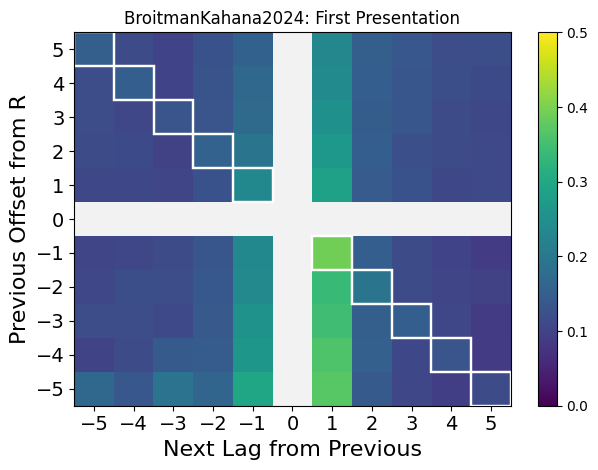

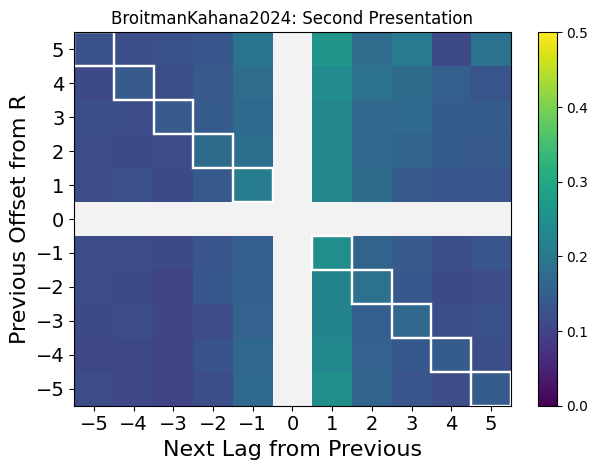

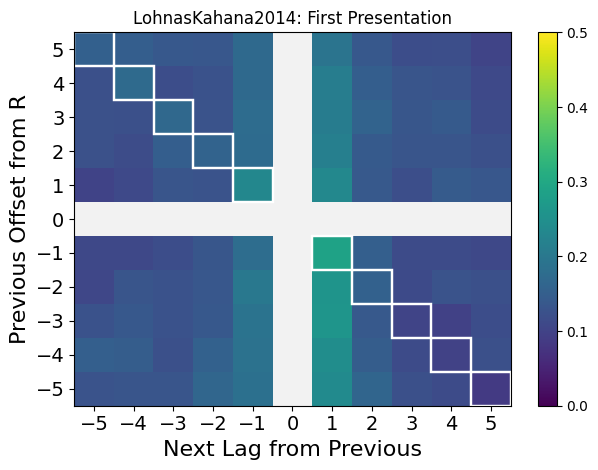

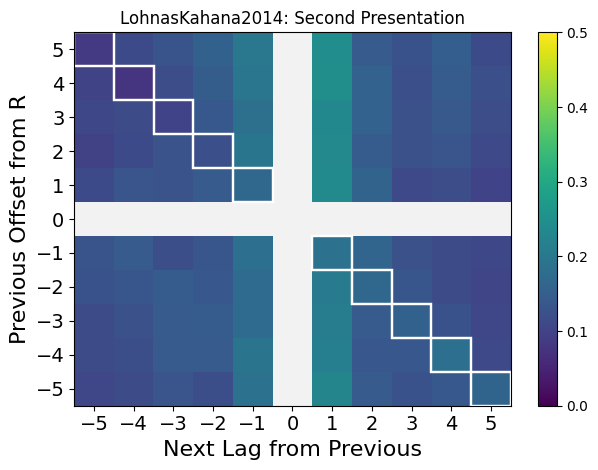

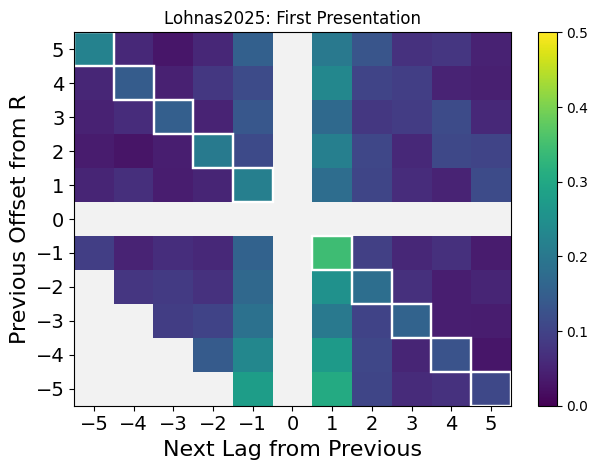

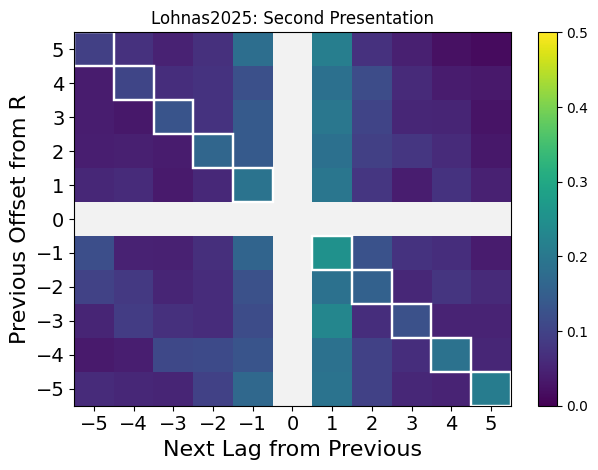

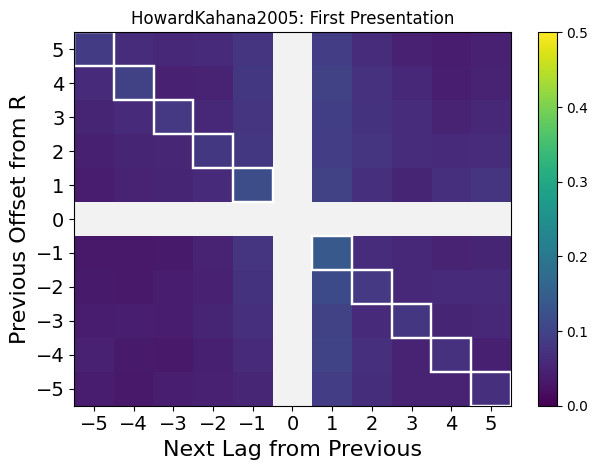

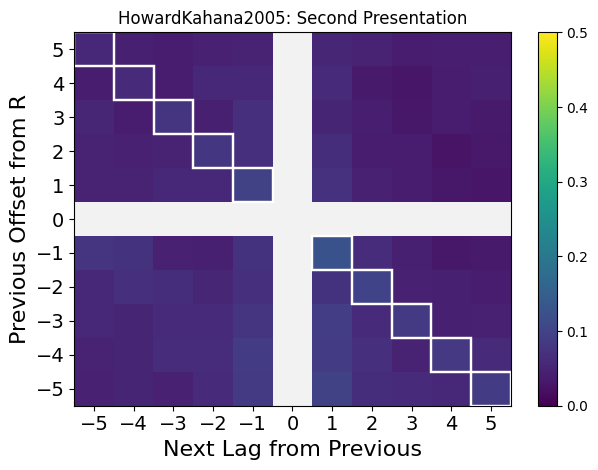

In [5]:
for source, subject_crp in zip(sources, observed_crps):
    for repetition_index, rep_label in enumerate(rep_labels):
        plt.figure()
        axis = plt.gca()
        surface = np.nanmean(subject_crp[:, repetition_index], axis=0)
        image = axis.imshow(
            np.ma.masked_invalid(surface),
            origin="lower",
            aspect="auto",
            cmap=_masked_cmap(),
            vmin=heatmap_vmin,
            vmax=heatmap_vmax,
            extent=[
                -max_lag - 0.5,
                max_lag + 0.5,
                -max_offset - 0.5,
                max_offset + 0.5,
            ],
        )
        axis.figure.colorbar(image, ax=axis)
        axis.set_xticks(lag_labels)
        axis.set_yticks(cue_offset_labels)
        axis.set_xlabel("Next Lag from Previous", fontsize=16)
        axis.set_ylabel("Previous Offset from R", fontsize=16)
        axis.tick_params(labelsize=14)
        _overlay_access_cells(axis, max_offset=max_offset, max_lag=max_lag)
        plt.title(f"{source}: {rep_label} Presentation")
        save_figure(
            figure_dir,
            figure_str,
            suffix=f"{source.lower()}_surface_{rep_label.lower()}",
        )

/var/folders/7n/m1dxq2r12b77t0c09mty9kn00000gn/T/ipykernel_69190/2430102530.py:8: RuntimeWarning: Mean of empty slice
  surface = np.nanmean(offset_surface[:, repetition_index], axis=0)


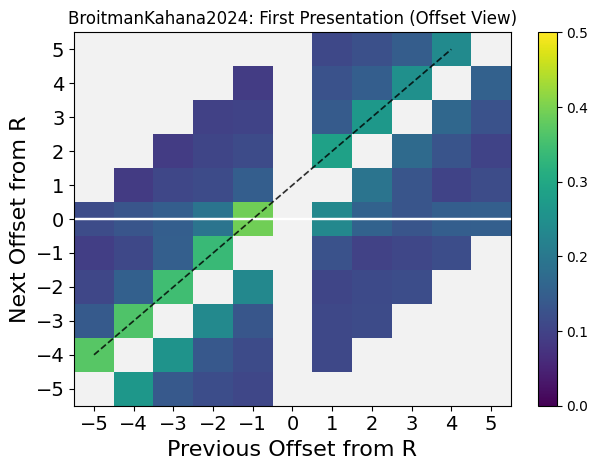

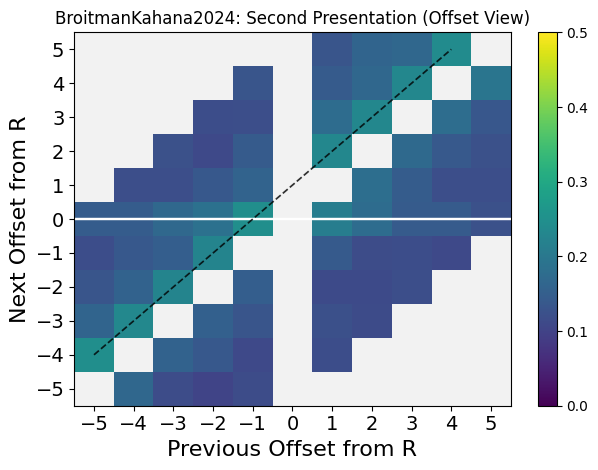

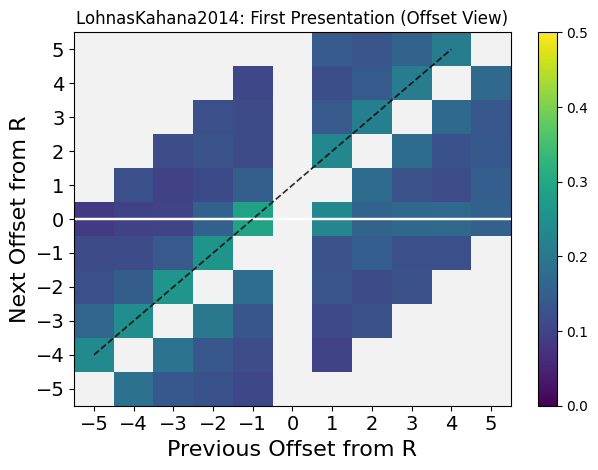

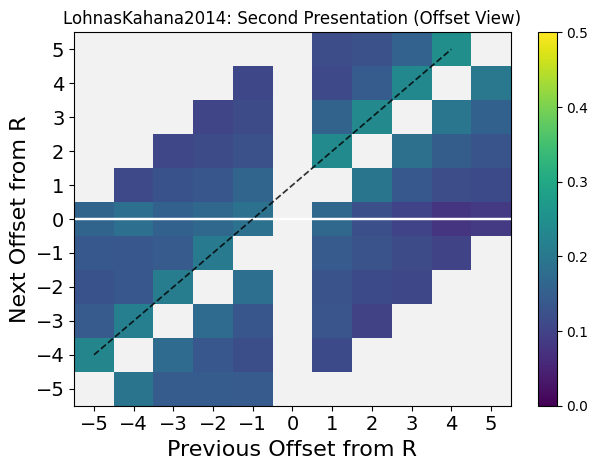

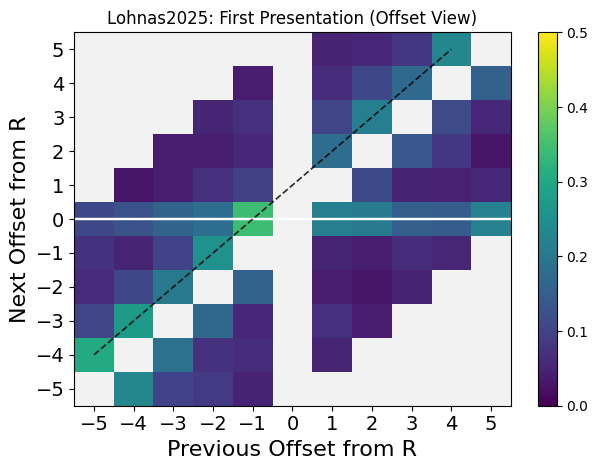

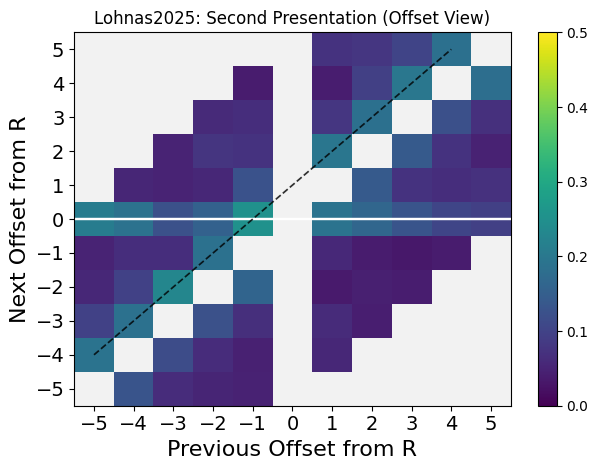

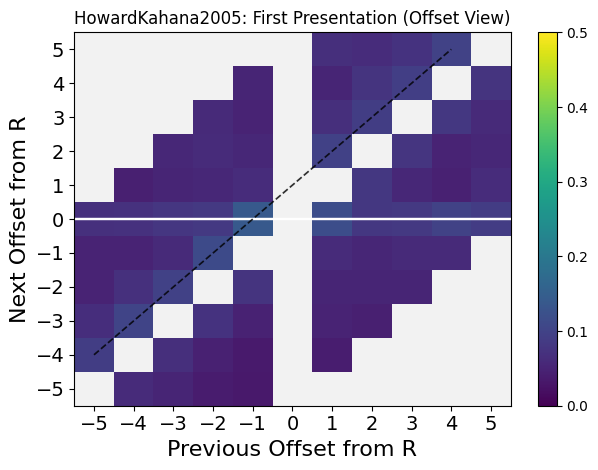

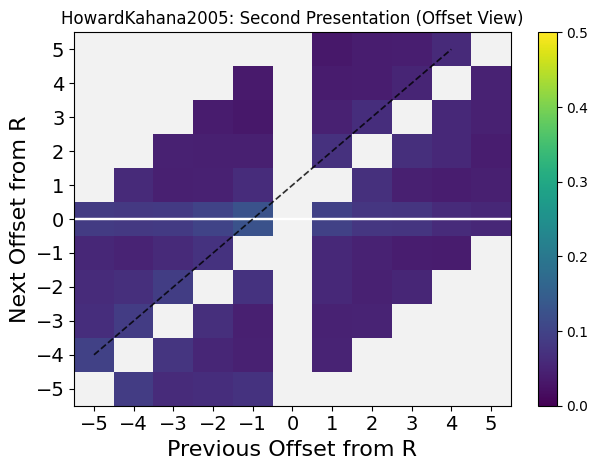

In [6]:
for source, subject_crp in zip(sources, observed_crps):
    _, offset_surface = _previous_next_surface(
        subject_crp, max_offset=max_offset, max_lag=max_lag
    )
    for repetition_index, rep_label in enumerate(rep_labels):
        plt.figure()
        axis = plt.gca()
        surface = np.nanmean(offset_surface[:, repetition_index], axis=0)
        image = axis.imshow(
            np.ma.masked_invalid(surface),
            origin="lower",
            aspect="auto",
            cmap=_masked_cmap(),
            vmin=heatmap_vmin,
            vmax=heatmap_vmax,
            extent=[
                -max_offset - 0.5,
                max_offset + 0.5,
                -max_offset - 0.5,
                max_offset + 0.5,
            ],
        )
        axis.figure.colorbar(image, ax=axis)
        axis.set_xticks(cue_offset_labels)
        axis.set_yticks(cue_offset_labels)
        axis.set_xlabel("Previous Offset from R", fontsize=16)
        axis.set_ylabel("Next Offset from R", fontsize=16)
        axis.tick_params(labelsize=14)
        axis.axhline(0, color="white", linewidth=1.75)
        x_values = cue_offset_labels
        y_values = cue_offset_labels + 1
        valid = (y_values >= -max_offset) & (y_values <= max_offset)
        axis.plot(
            x_values[valid],
            y_values[valid],
            linestyle="--",
            color="black",
            linewidth=1.25,
            alpha=0.8,
        )
        plt.title(f"{source}: {rep_label} Presentation (Offset View)")
        save_figure(
            figure_dir,
            figure_str,
            suffix=f"{source.lower()}_offset_surface_{rep_label.lower()}",
        )

/Users/jordangunn/miniconda3/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


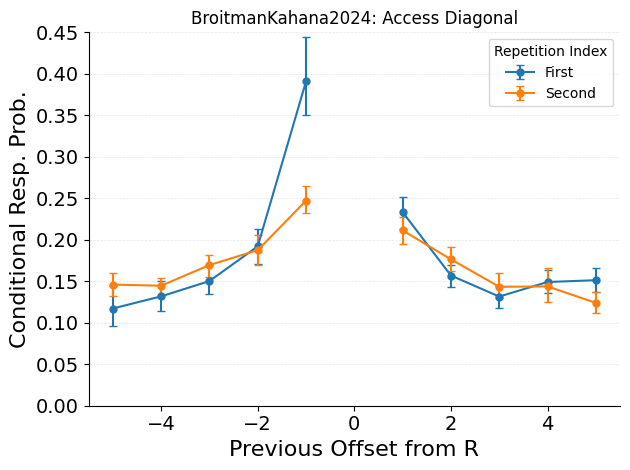

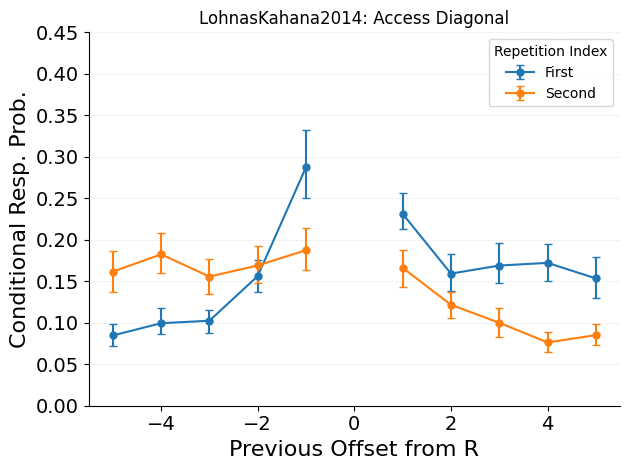

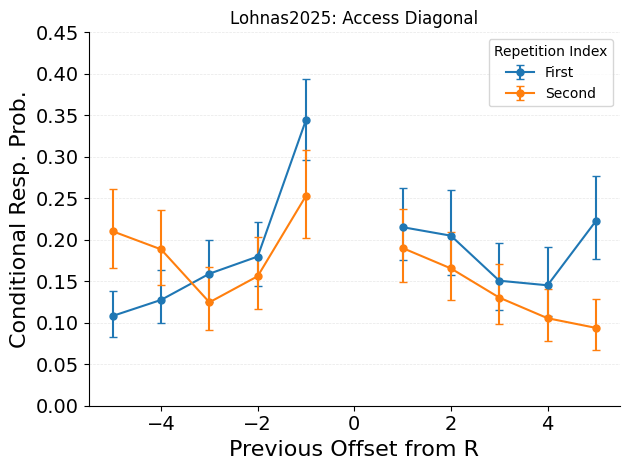

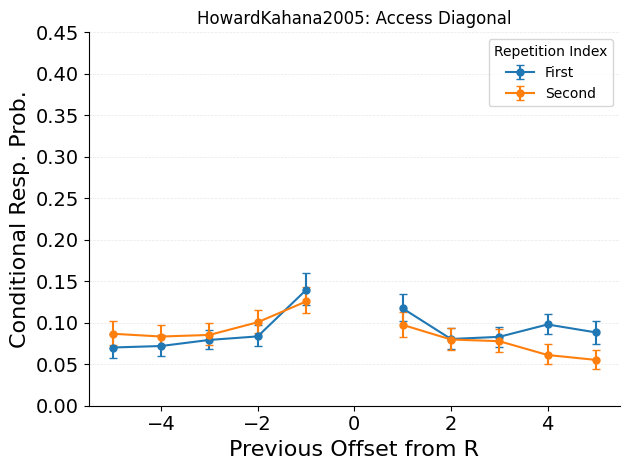

In [7]:
color_cycle = [each["color"] for each in plt.rcParams["axes.prop_cycle"]]

for source, subject_crp in zip(sources, observed_crps):
    plt.figure()
    axis = plt.gca()
    access_crp = access_diagonal(subject_crp)
    for repetition_index, rep_label in enumerate(rep_labels):
        plot_data(
            axis,
            access_offset_labels,
            access_crp[:, repetition_index, :],
            rep_label,
            color_cycle[repetition_index % len(color_cycle)],
            confidence_level=confidence_level,
        )
    set_plot_labels(axis, "Previous Offset from R", "Conditional Resp. Prob.", "Repetition Index")
    plt.title(f"{source}: Access Diagonal")
    if ylim is not None:
        axis.set_ylim(ylim)
    save_figure(figure_dir, figure_str, suffix=f"{source.lower()}_access_diagonal")

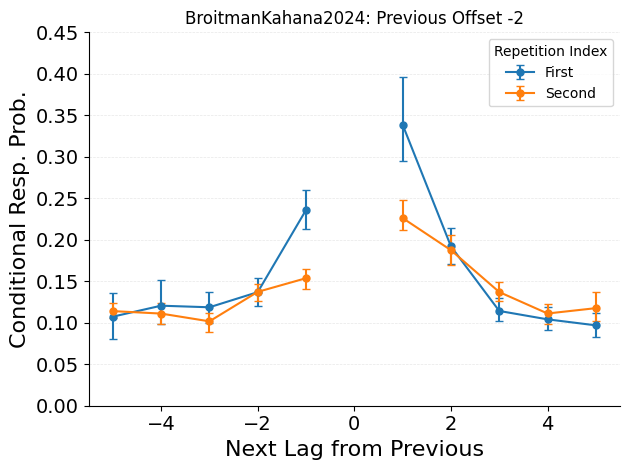

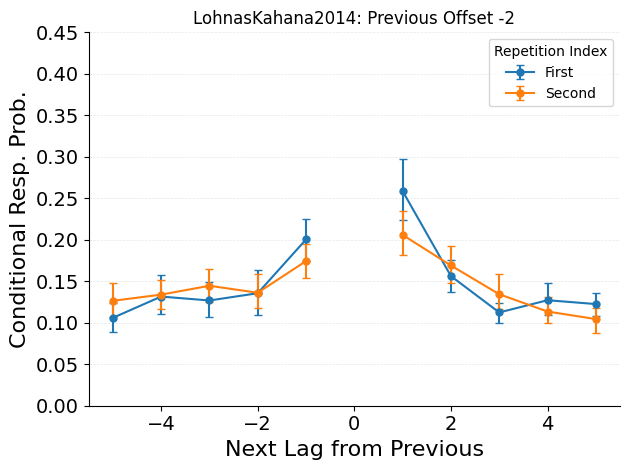

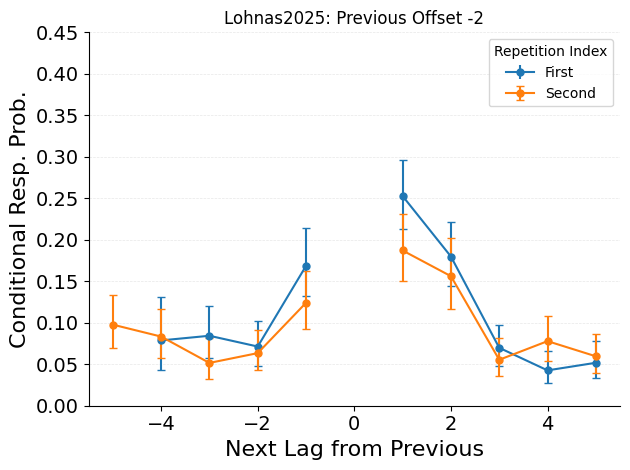

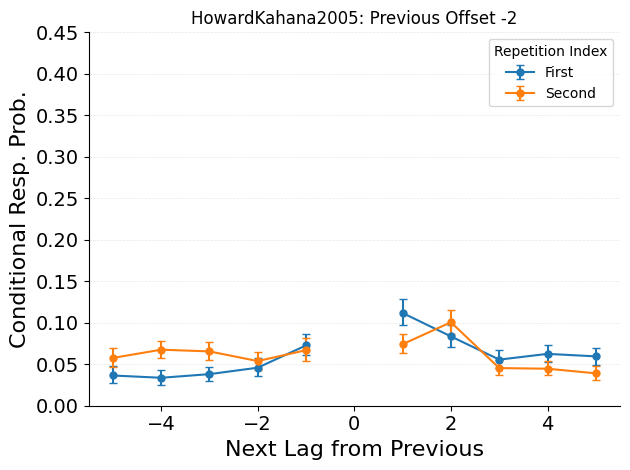

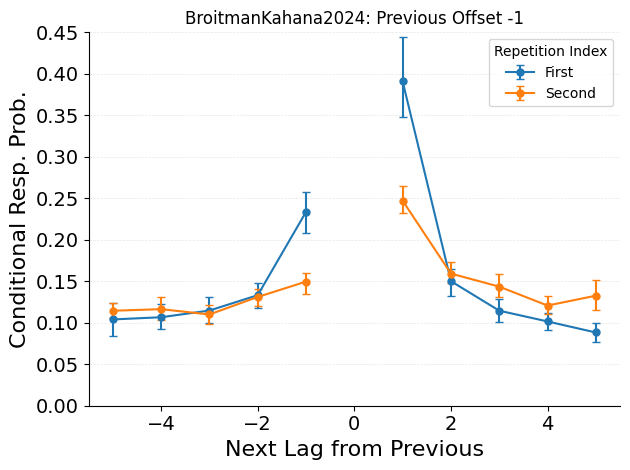

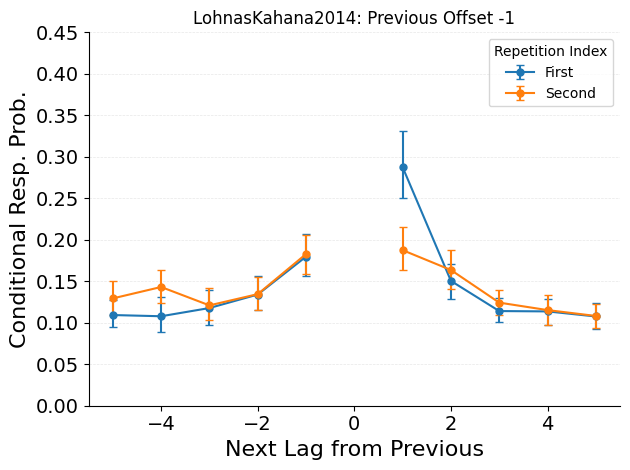

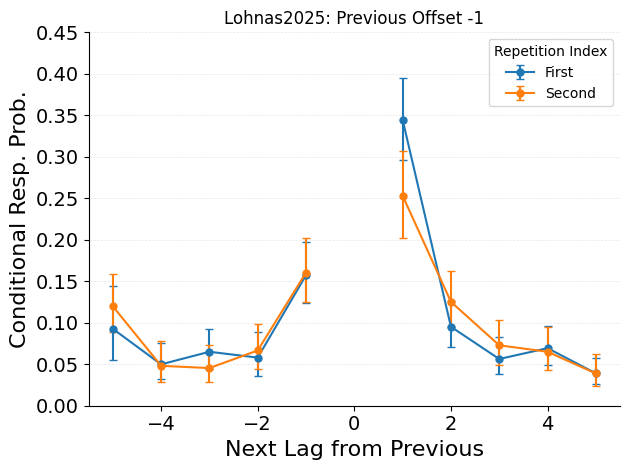

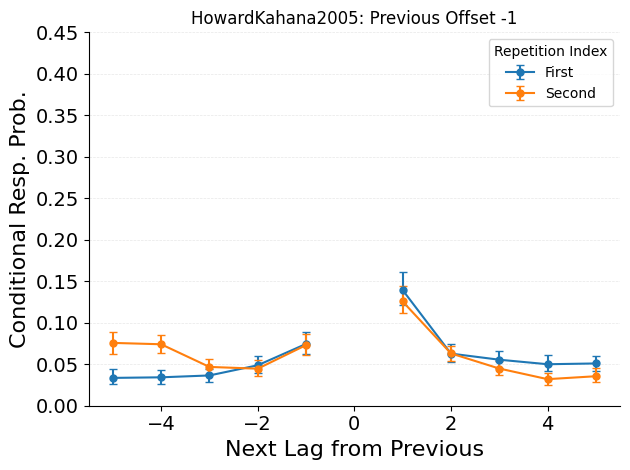

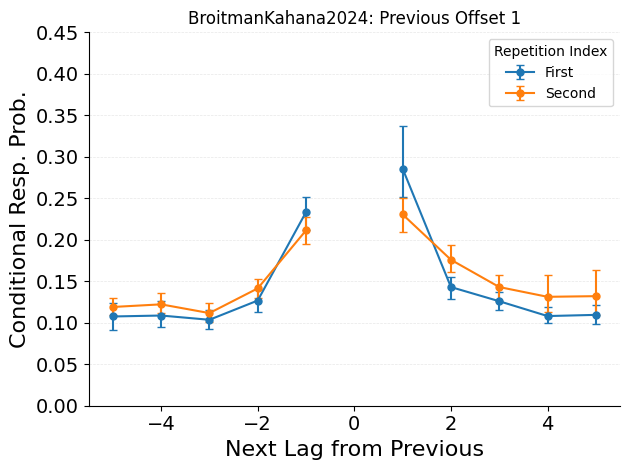

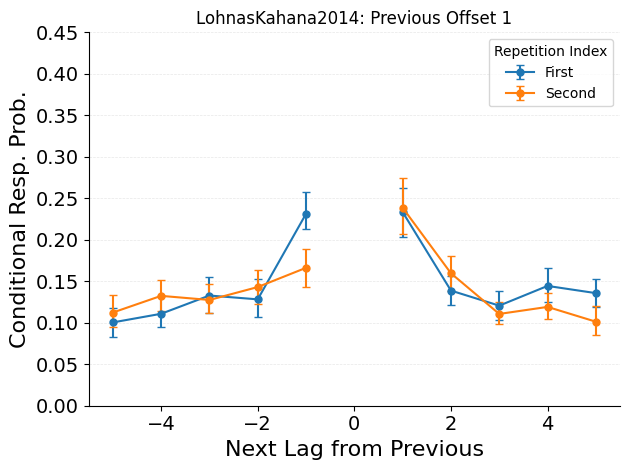

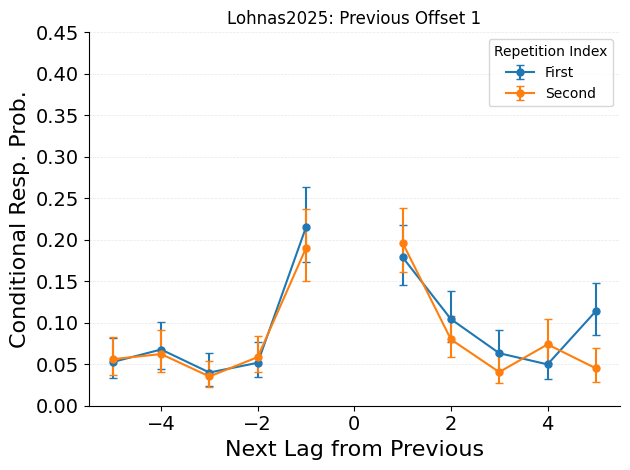

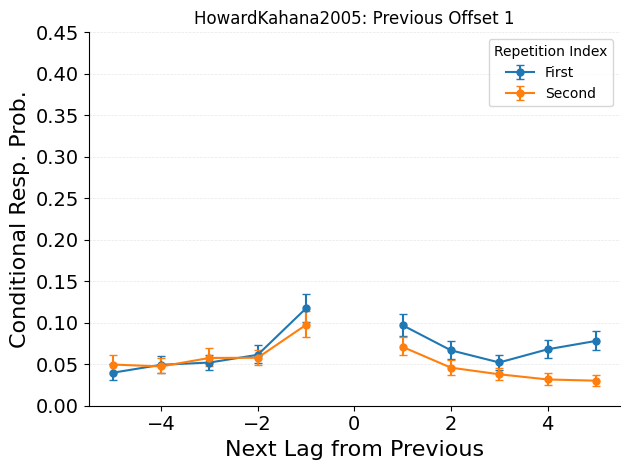

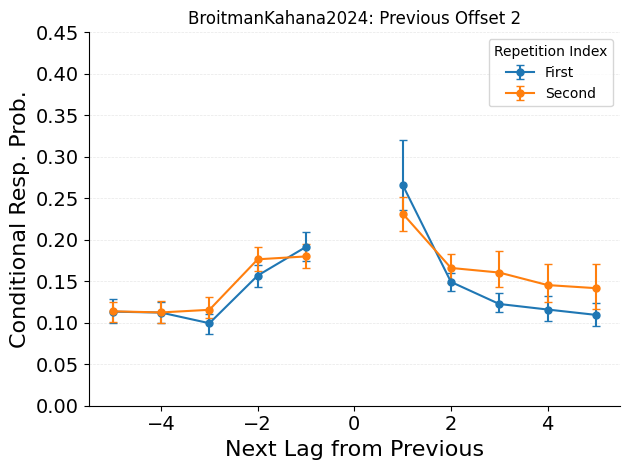

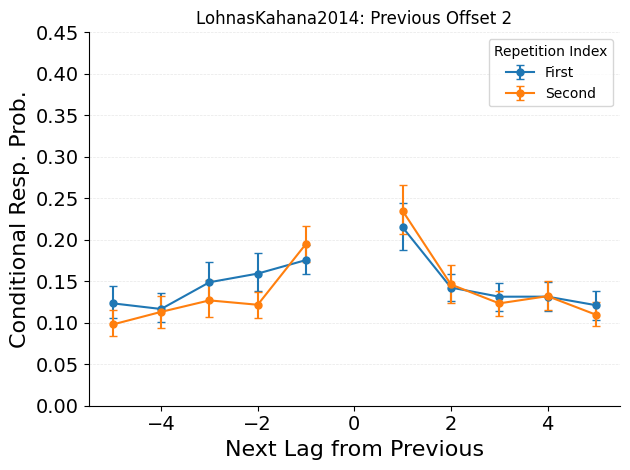

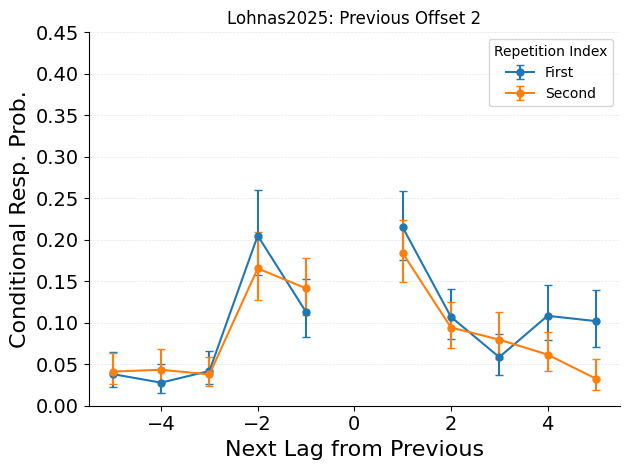

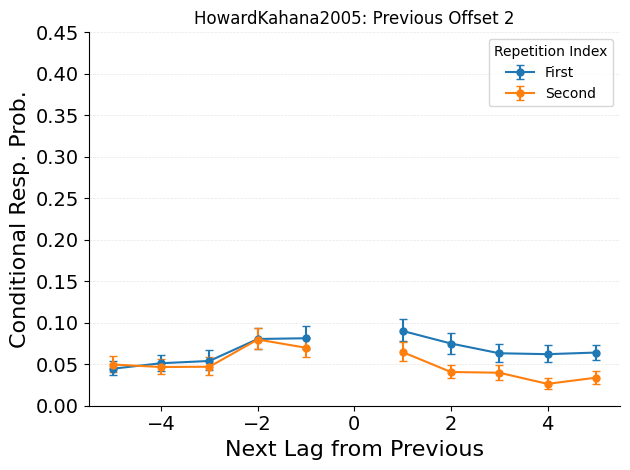

In [8]:
for cue_offset in cue_offsets_to_plot:
    for source, subject_crp in zip(sources, observed_crps):
        plt.figure()
        axis = plt.gca()
        offset_values = subject_crp[:, :, cue_offset + max_offset, :]
        for repetition_index, rep_label in enumerate(rep_labels):
            plot_data(
                axis,
                lag_labels,
                offset_values[:, repetition_index, :],
                rep_label,
                color_cycle[repetition_index % len(color_cycle)],
                confidence_level=confidence_level,
            )
        set_plot_labels(axis, "Next Lag from Previous", "Conditional Resp. Prob.", "Repetition Index")
        plt.title(f"{source}: Previous Offset {cue_offset}")
        if ylim is not None:
            axis.set_ylim(ylim)
        save_figure(figure_dir, figure_str, suffix=f"{source.lower()}_offset_{cue_offset}")

## Interpretation

The first surface plots show the original prior-conditioned CRP: previous offset is the prior recalled item's serial-position offset from a repeated-item occurrence, and next lag is the ordinary forward lag from that just-recalled item to the next recalled item. Outlined cells mark transitions in which the next recall is the repeated item.

The second surface plots transform the same values into previous-offset by next-offset coordinates. In this view, access to the repeated item is always the `next offset = 0` row, and ordinary +1 contiguity lies on the dashed `next = previous + 1` line.

The access-diagonal plot extracts cells where `next lag = -previous offset`. These are the transitions in which the next recall is the repeated item occurrence defining the offset. This diagonal is the focused repeated-item access measure while preserving the ordinary forward-CRP denominator.

The offset-specific CRP plots show ordinary transition-lag curves after prior recalls that were at selected offsets from first or second repeated-item presentations. Their x-axis is not lag from the repeater; it is lag from the just-recalled item.

## API Details

### Notebook parameters

- `data_paths`: paths to HDF5 files containing `RecallDataset` objects with repeated items.
- `trial_queries`: queries selecting trials for each dataset.
- `data_labels`: display labels for each dataset.
- `ylim`: y-axis limits shared across datasets, or `None` for automatic scaling.
- `min_lag`: minimum spacing between repeated presentations.
- `max_offset`: maximum previous/next offset shown and tested.
- `max_lag`: maximum ordinary transition lag shown and tested.
- `cue_offsets_to_plot`: selected previous offsets for ordinary CRP curves.

### Analysis functions

- `subject_rep_cue_crp(...)` returns subject-level arrays with shape `(subjects, repetition_index, previous_offset, next_lag)`.
- `plot_rep_cue_crp_surface(...)` displays the previous-offset by next-lag surface and marks access-to-repeater cells.
- `plot_rep_cue_offset_surface(...)` displays the transformed previous-offset by next-offset surface.
- `plot_rep_cue_access_crp(...)` displays the diagonal `next lag = -previous offset`, with offset 0 left empty so the line breaks at the repeated item.
- `plot_rep_cue_crp(...)` displays an ordinary transition-lag CRP for one previous offset.

Unlike target-conditioned access summaries, this is a forward prior-conditioned CRP. It conditions on a prior observed recall and asks what transition lags follow from that state.